In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates
import datetime as dt
import urllib.request


In [15]:
bonneville = pd.read_excel("Bonneville_Salt_Flat_08_05_2025_logs.xlsx") # high albedo data taken from bonneville salt flats aug 2025. See Griffies 2025 slc colabaration meeting presentation
car_park = pd.read_excel("08_04_2025_logs.xlsx") # low albedo taken from parking lot aug 2025. See same presentation
lssb = pd.read_csv('spo26_177.csv') # concreat albedo data taken at LSSB building u of u at 3 angles: up↑, down↓, middle→. june 2026. Want to see if this matches a model made by the tests from last year which did not go to this extream of angles



In [16]:
bonneville
bonneville_power = bonneville['Power Output Calculated'].to_numpy()
bonneville_altitude = bonneville['Altitude (deg)'].to_numpy()[:35]
bonneville_gamma = bonneville['Gamma (deg)'].to_numpy()[:35]
# bonneville_mean_power = bonneville['Mean Power Calculated'].to_numpy()[:35]

# print(bonneville_power)
# print(bonneville_altitude)
# print(bonneville_gamma)



In [17]:
car_park
car_park_power = car_park['Power Output Calculated'].to_numpy()
car_park_altitude = car_park['Altitude (deg)'].to_numpy()[:35]
car_park_gamma = car_park['Gamma (deg)'].to_numpy()[:35]
# car_park_mean_power = car_park['Mean Power Calculated'].to_numpy()[:35]

# print(car_park_power)
# print(car_park_altitude)
# print(car_park_gamma)



In [18]:
# Remove NO RESPONSE rows
# lssb = lssb[lssb["Response"] == "OK"]
lssb

# === Gemini Code for getting time ranges ===
# ==== up facing panel ===
# 1. Convert the Time column to datetime to pull out the hour and minute easily
time_dt = pd.to_datetime(lssb['Time'], format='%H:%M:%S').dt

# 2. Create the mask for times between 14:10:00 and 14:20:00 (inclusive)
time_mask_up = (time_dt.time >= pd.to_datetime('14:10:00').time()) & \
            (time_dt.time <= pd.to_datetime('14:20:00').time())

# 3. Apply the mask and select the 'Voltage' column
lssb_voltage_up = lssb.loc[time_mask_up, 'Voltage']
lssb_current_up = lssb.loc[time_mask_up, 'Current']
# === down facing panel === 
# 1. Convert the Time column to datetime to pull out the hour and minute easily
time_dt = pd.to_datetime(lssb['Time'], format='%H:%M:%S').dt

# 2. Create the mask for times between 14:10:00 and 14:20:00 (inclusive)
time_mask_down = (time_dt.time >= pd.to_datetime('14:21:00').time()) & \
            (time_dt.time <= pd.to_datetime('14:30:00').time())

# 3. Apply the mask and select the 'Voltage' column
lssb_voltage_down = lssb.loc[time_mask_down, 'Voltage']
lssb_current_down = lssb.loc[time_mask_down, 'Current']
# === side facing panel === 
# 1. Convert the Time column to datetime to pull out the hour and minute easily
time_dt = pd.to_datetime(lssb['Time'], format='%H:%M:%S').dt

# 2. Create the mask for times between 14:10:00 and 14:20:00 (inclusive)
time_mask_side = (time_dt.time >= pd.to_datetime('14:32:00').time()) & \
            (time_dt.time <= pd.to_datetime('14:45:00').time())

# 3. Apply the mask and select the 'Voltage' column
lssb_voltage_side = lssb.loc[time_mask_side, 'Voltage']
lssb_current_side = lssb.loc[time_mask_side, 'Current']
# ===========================================




lssb_power = lssb['Voltage'].to_numpy()*lssb['Current'].to_numpy()

lssb_power_up = (lssb_voltage_up.to_numpy())*(lssb_current_up.to_numpy())
lssb_power_down = (lssb_voltage_down.to_numpy())*(lssb_current_down.to_numpy())
lssb_power_side = (lssb_voltage_side.to_numpy())*(lssb_current_side.to_numpy())


# plt.plot(lssb_power_side)




0      -0.4
1      -0.4
2      -0.2
3       0.0
4       0.1
       ... 
1436    8.3
1437    9.3
1438    6.4
1439    8.4
1440    NaN
Name: 10, Length: 1441, dtype: float64
0       17.8
1       18.0
2       18.2
3       18.4
4       18.6
        ... 
1436    25.1
1437    25.3
1438    25.3
1439    25.3
1440     NaN
Name: 14, Length: 1441, dtype: float64
0       147.4
1       150.4
2       153.3
3       155.9
4       158.5
        ...  
1436    252.9
1437    254.3
1438    254.4
1439    253.5
1440      NaN
Name: 12, Length: 1441, dtype: float64


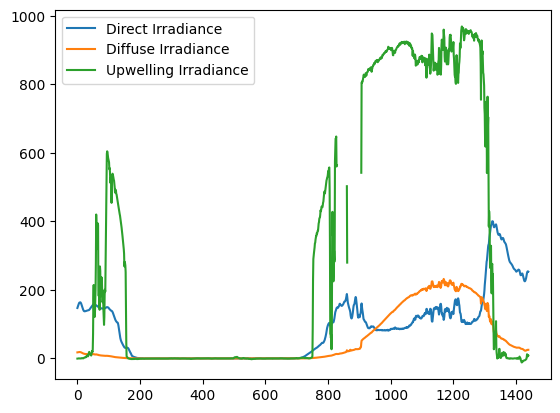

In [22]:
# Get NOAA irradiance data for the day we did the jun 26 2026 upwelling test
# https://gml.noaa.gov/aftp/data/radiation/solrad/slc/2026/slc26177.dat

baseurl = 'https://gml.noaa.gov/aftp/data/radiation/solrad/slc/2026/slc26177.dat'
InputPath = '../../DataFolder'
OutputPath = 'PlotsFolder/'

# import NOAA data function
def Import_NOAA_Data():
    
    
    
    # -----------------NOAA-----------------------------------
    
    filename = f'{baseurl}' #construct the full filename
    # print(filename) #print the filename being accessed
    
    try:
        file = urllib.request.urlopen(filename)
        data = file.read().decode('utf-8').split('\n') #read the file and split into lines
        #convert data to dataframe
        df = pd.DataFrame([row.split() for row in data[2:]])
        # print(dt)
    except urllib.error.HTTPError:
        print()
        # print(f"{filename} file not found") #print error if file not found
    
    # print('dir Irradiance data time correction')
    '''Direct Irradiance'''
    #define the direct irradiance and diffuse irradiance data with time correction for NZDT
    
    NZDTdir_ir = df[12]
    #convert this to float
    NZDTdir_ir = NZDTdir_ir.astype(float)
    #remove nan values from NZDTdir_ir 
    NZDTdir_ir[NZDTdir_ir == -9999.9] = np.nan
    # NZDTdir_ir = np.array([random.randint(950, 1000) for _ in range(1440)]) # Generate a random integer between 950 and 1050
    # NZDTdir_ir = NZDTdir_ir.astype(float)
    # print(len(NZDTdir_ir))

    # print(NZDTdir_ir)
    
    # print('diff Irradiance data time correction')
    ''' Diffuse irradiance'''
    # diffuse irradiance
    
    NZDTdiff_ir= df[14]
    NZDTdiff_ir = NZDTdiff_ir.astype(float) #convert this to float
    
    #remove nan values from NZDTdiff_ir 
    NZDTdiff_ir[NZDTdiff_ir == -9999.9] = np.nan #remove nan values
    # NZDTdiff_ir = np.array([random.randint(250, 350) for _ in range(1440)]) # Generate a random integer between 250 and 400
    # NZDTdiff_ir = NZDTdiff_ir.astype(float) #convert this to float
    
    ''' Upwelling irradiance'''
    #upwelling irradiance
    
    NZDTup_ir= df[10]
    NZDTup_ir = NZDTup_ir.astype(float) #convert this to float
    #remove nan values from NZDTup_ir 
    NZDTup_ir[NZDTup_ir == -9999.9] = np.nan
    # NZDTup_ir = np.array([random.randint(500, 600) for _ in range(1440)]) # Generate a random integer between 50 and 150
    # NZDTup_ir = NZDTup_ir.astype(float)
    
    '''Time List'''
    # print(NZDTdiff_ir)
    # Create a range of timestamps with a frequency of 1 minute ('min')
    times_list = pd.date_range("00:00:00", periods=1440, freq="min")
    
    # Format as HH:MM:SS strings
    NOAA_time = times_list.strftime("%H:%M:%S").tolist()    
    NOAA_time = pd.to_timedelta(pd.Series(NOAA_time))
    NOAA_time = NOAA_time.astype(str).str.split().str[-1]
    
    #time list for the device data
    times_list_device = pd.date_range("00:00:00", periods=2880, freq="min")
    
    # Format as HH:MM:SS strings
    device_time = times_list_device.strftime("%H:%M:%S").tolist()    
    device_time = pd.to_timedelta(pd.Series(device_time))
    device_time = device_time.astype(str).str.split().str[-1]
    
    # print(NOAA_time[:10],file_103['Time'][:10])
    #Calculate the solar angle for the given day of the year, this is from the solar angle formula

    '''Solar Zenith Angle'''
    
    NZDT_Zenith= df[7]
    NZDT_Zenith = NZDT_Zenith.astype(float)
    #remove nan values from NZDTup_ir 
    NZDT_Zenith[NZDT_Zenith == -9999.9] = np.nan
    

    # ---------------------------------------------------------------
    return NZDTdir_ir,NZDTdiff_ir, NZDTup_ir, NOAA_time, NZDT_Zenith


direct_irradiance, diffuse_irradiance, upwelling_irradiance, NOAA_time, zenith = Import_NOAA_Data()
plt.plot(direct_irradiance, label = 'Direct Irradiance')
plt.plot(diffuse_irradiance, label = 'Diffuse Irradiance')
print(upwelling_irradiance)
print(diffuse_irradiance)
print(direct_irradiance)
plt.plot(upwelling_irradiance, label = 'Upwelling Irradiance')
plt.legend()
plt.show()





3.9774149999999997
0.09135294117647058
0.8707777777777778
[5.6        5.6        5.56190476 5.56190476 5.6        4.36190476
 4.4952381  4.36190476 4.62857143 4.62857143 4.4952381  4.28571429
 3.58095238 3.40952381 3.58095238 2.4        2.36190476 2.47619048
 2.41904762 2.41904762 1.39047619 1.40952381 0.4952381  0.51428571
 0.95238095 1.39047619 1.33333333 0.45714286 0.8952381  0.4       ]
[-8.81081081e-01 -8.35135135e-01 -8.05405405e-01 -7.59459459e-01
 -7.21621622e-01 -7.32432432e-01 -6.97297297e-01 -6.35135135e-01
 -4.40540541e-01 -4.24324324e-01 -4.02702703e-01 -3.67567568e-01
 -3.24324324e-01  2.22044605e-16  2.22044605e-16  3.24324324e-01
  3.64864865e-01  4.40540541e-01  4.13513514e-01  4.00000000e-01
  5.59459459e-01  6.32432432e-01  6.43243243e-01  7.35135135e-01
  7.21621622e-01  6.97297297e-01  7.62162162e-01  8.08108108e-01
  8.35135135e-01  8.78378378e-01]


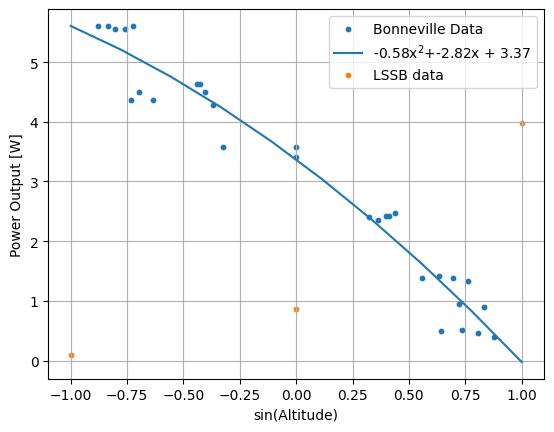

In [52]:
print(np.nanmean(lssb_power_up))
print(np.nanmean(lssb_power_down))
print(np.nanmean(lssb_power_side))
lssb_power_up_mean = np.nanmean(lssb_power_up)
lssb_power_down_mean = np.nanmean(lssb_power_down)
lssb_power_side_mean = np.nanmean(lssb_power_side)

upwelling_webplotdigitizer_array = np.loadtxt('Bonneville_Upwelling_Combined_WebPlotDigitizer.csv', delimiter = ',') #quick and dirty way
# print(upwelling_webplotdigitizer_array)
# print()
# print(upwelling_webplotdigitizer_array[:,0])
# print()
# print(upwelling_webplotdigitizer_array[:,1])

power_upwelling_webplotdigitizer = upwelling_webplotdigitizer_array[:,1]
cos_altitude_upwelling_webplotdigitizer = upwelling_webplotdigitizer_array[:,0]
print(power_upwelling_webplotdigitizer)
print(cos_altitude_upwelling_webplotdigitizer)

a,b,c = np.polyfit(cos_altitude_upwelling_webplotdigitizer, power_upwelling_webplotdigitizer, 2)

plt.scatter(cos_altitude_upwelling_webplotdigitizer, power_upwelling_webplotdigitizer, s = 10, label = 'Bonneville Data')
x_data_for_line_fit = np.linspace(-1,1,10)
plt.plot(x_data_for_line_fit, a*x_data_for_line_fit**2 + b*x_data_for_line_fit + c, label = fr'{np.round(a,2)}x$^2$+{np.round(b,2)}x + {np.round(c,2)}')
plt.scatter([-1,0,1],[lssb_power_down_mean, lssb_power_side_mean, lssb_power_up_mean], s = 10, label = 'LSSB data')
# plt.xlim(-1,1)
# plt.ylim(0,6)
plt.xlabel(r'sin(Altitude)')
plt.ylabel(r'Power Output [W]')

plt.grid('on')

plt.legend()



